In [1]:
setwd("~/Projects/R/ISLR2")

In [2]:
source("InstallAndLoadScripts/loadlibraries.R")

In [3]:
loadISLR2Libraries()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘ISLR2’


The following object is masked from ‘package:MASS’:

    Boston


Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘gridExtra’


The following object is mas

In [4]:
dim(Boston)

[1] 506  13

In [5]:
set.seed (1)
train = sample(1:nrow(Boston), 406)

In [6]:
write.csv(Boston, file = "/Users/rob/Projects/R/ISLR2/data/Boston_all.csv")
write.csv(Boston[train,], file = "/Users/rob/Projects/R/ISLR2/data/Boston_train.csv")
write.csv(Boston[-train,], file = "/Users/rob/Projects/R/ISLR2/data/Boston_test.csv")

In [7]:
tree.boston = tree(medv ~ ., Boston, subset = train)
summary(tree.boston)


Regression tree:
tree(formula = medv ~ ., data = Boston, subset = train)
Variables actually used in tree construction:
[1] "rm"    "lstat" "dis"   "crim" 
Number of terminal nodes:  7 
Residual mean deviance:  12.85 = 5128 / 399 
Distribution of residuals:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-17.7400  -2.0390   0.2604   0.0000   2.2760  17.2600 

In [8]:
sort(unique(Boston$medv))

[1]  5.0  5.6  6.3  7.0  7.2  7.4  7.5  8.1  8.3  8.4  8.5  8.7  8.8  9.5  9.6
 [16]  9.7 10.2 10.4 10.5 10.8 10.9 11.0 11.3 11.5 11.7 11.8 11.9 12.0 12.1 12.3
 [31] 12.5 12.6 12.7 12.8 13.0 13.1 13.2 13.3 13.4 13.5 13.6 13.8 13.9 14.0 14.1
 [46] 14.2 14.3 14.4 14.5 14.6 14.8 14.9 15.0 15.1 15.2 15.3 15.4 15.6 15.7 16.0
 [61] 16.1 16.2 16.3 16.4 16.5 16.6 16.7 16.8 17.0 17.1 17.2 17.3 17.4 17.5 17.6
 [76] 17.7 17.8 17.9 18.0 18.1 18.2 18.3 18.4 18.5 18.6 18.7 18.8 18.9 19.0 19.1
 [91] 19.2 19.3 19.4 19.5 19.6 19.7 19.8 19.9 20.0 20.1 20.2 20.3 20.4 20.5 20.6
[106] 20.7 20.8 20.9 21.0 21.1 21.2 21.4 21.5 21.6 21.7 21.8 21.9 22.0 22.1 22.2
[121] 22.3 22.4 22.5 22.6 22.7 22.8 22.9 23.0 23.1 23.2 23.3 23.4 23.5 23.6 23.7
[136] 23.8 23.9 24.0 24.1 24.2 24.3 24.4 24.5 24.6 24.7 24.8 25.0 25.1 25.2 25.3
[151] 26.2 26.4 26.5 26.6 26.7 27.0 27.1 27.5 27.9 28.0 28.1 28.2 28.4 28.5 28.6
[166] 28.7 29.0 29.1 29.4 29.6 29.8 29.9 30.1 30.3 30.5 30.7 30.8 31.0 31.1 31.2
[181] 31.5 31.6 31.7 32.0 32.2 32.4 32.5 32.7 32.9 33.0 33.1 33.2 33.3 33.4 33.8
[196] 34.6 34.7 34.9 35.1 35.2 35.4 36.0 36.1 36.2 36.4 36.5 37.0 37.2 37.3 37.6
[211] 37.9 38.7 39.8 41.3 41.7 42.3 42.8 43.1 43.5 43.8 44.0 44.8 45.4 46.0 46.7
[226] 48.3 48.5 48.8 50.0

In [9]:
length(sort(unique(Boston$medv)))

[1] 229

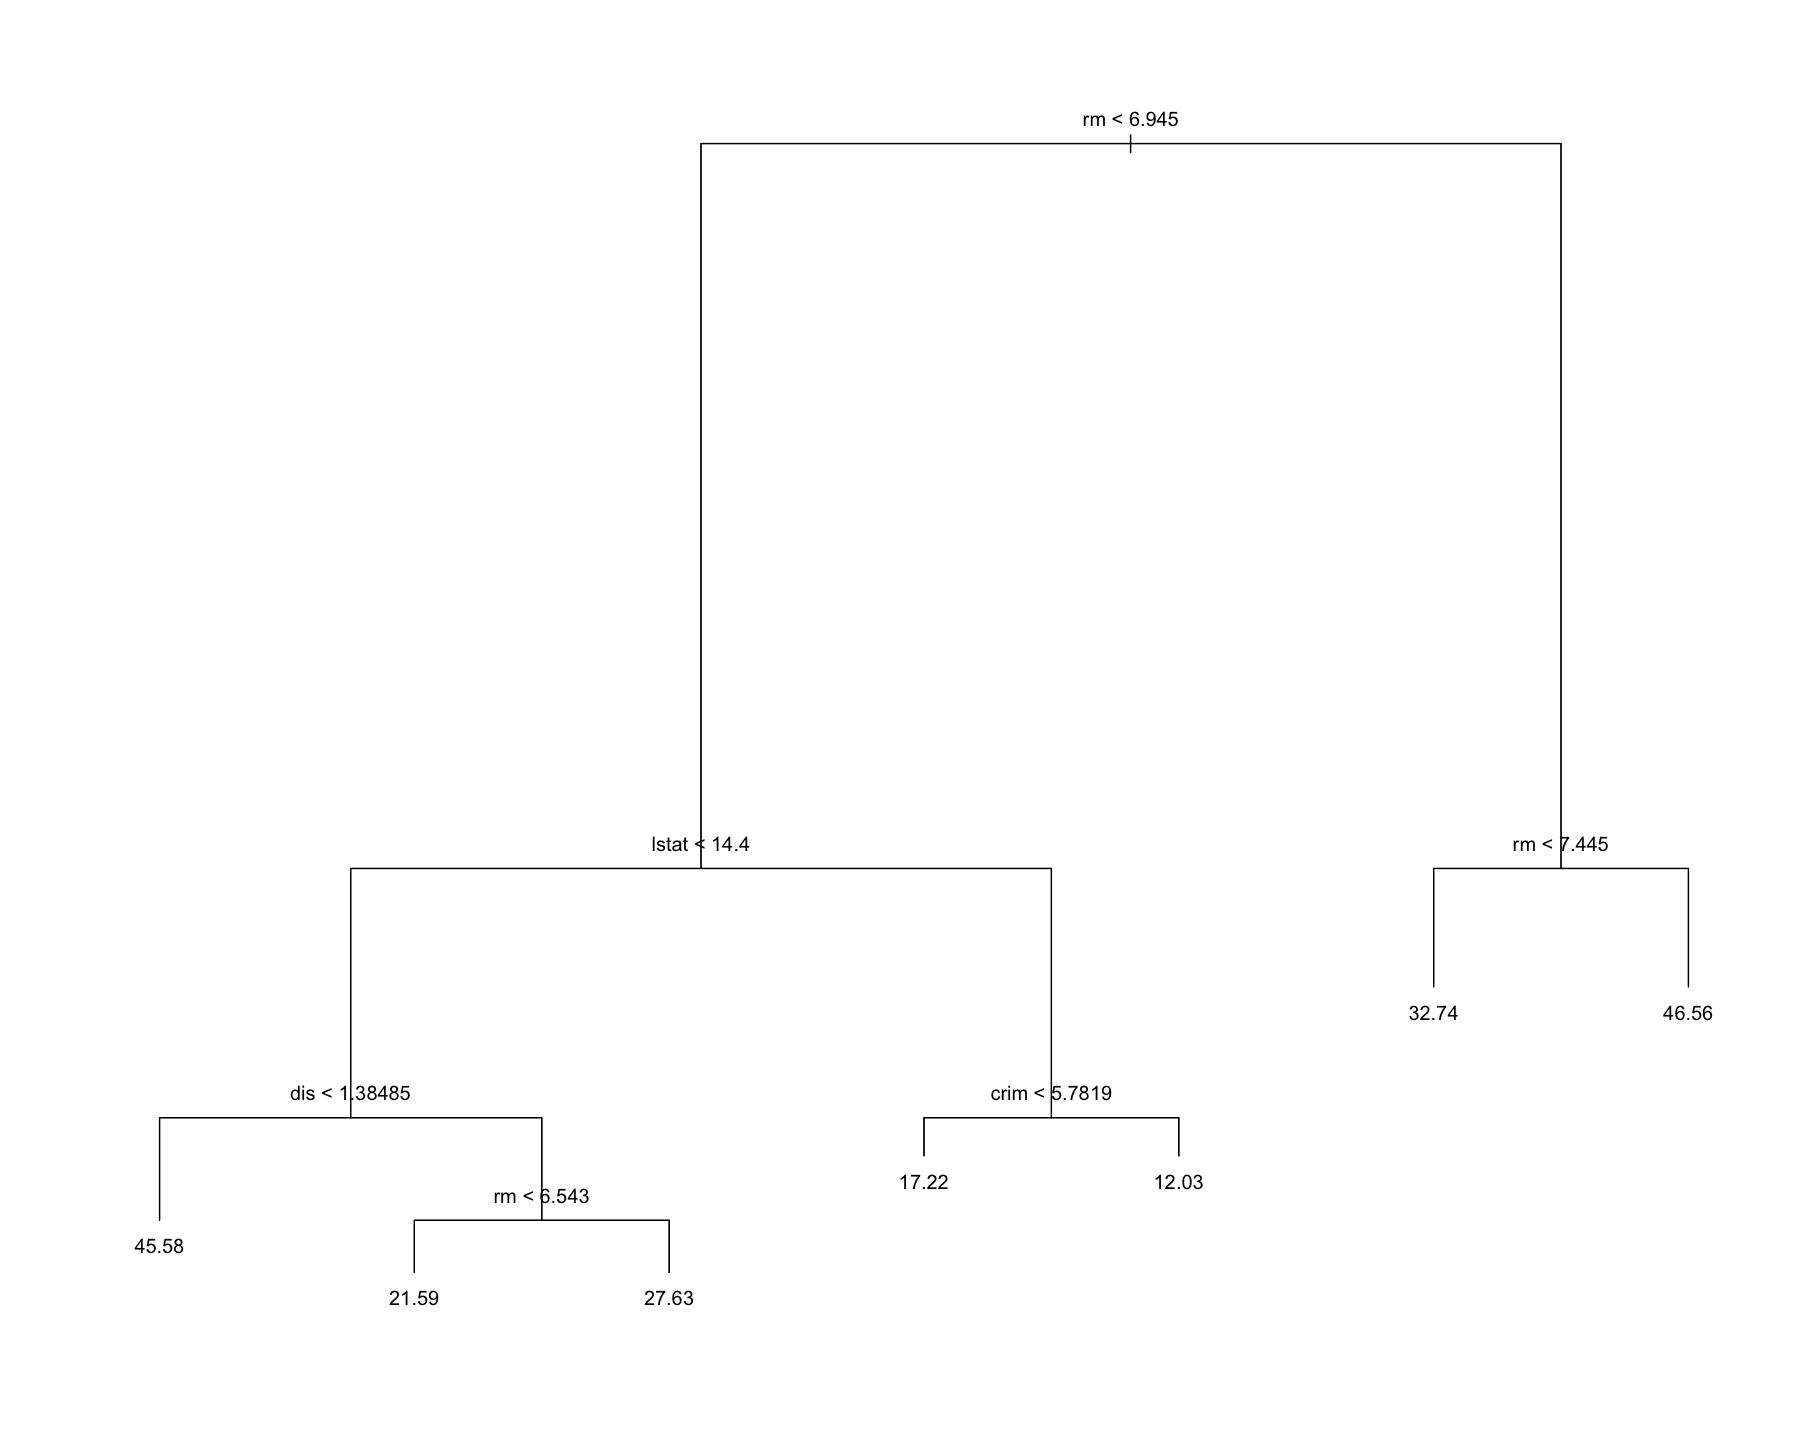

In [10]:
plot(tree.boston)
text(tree.boston, pretty = 0)

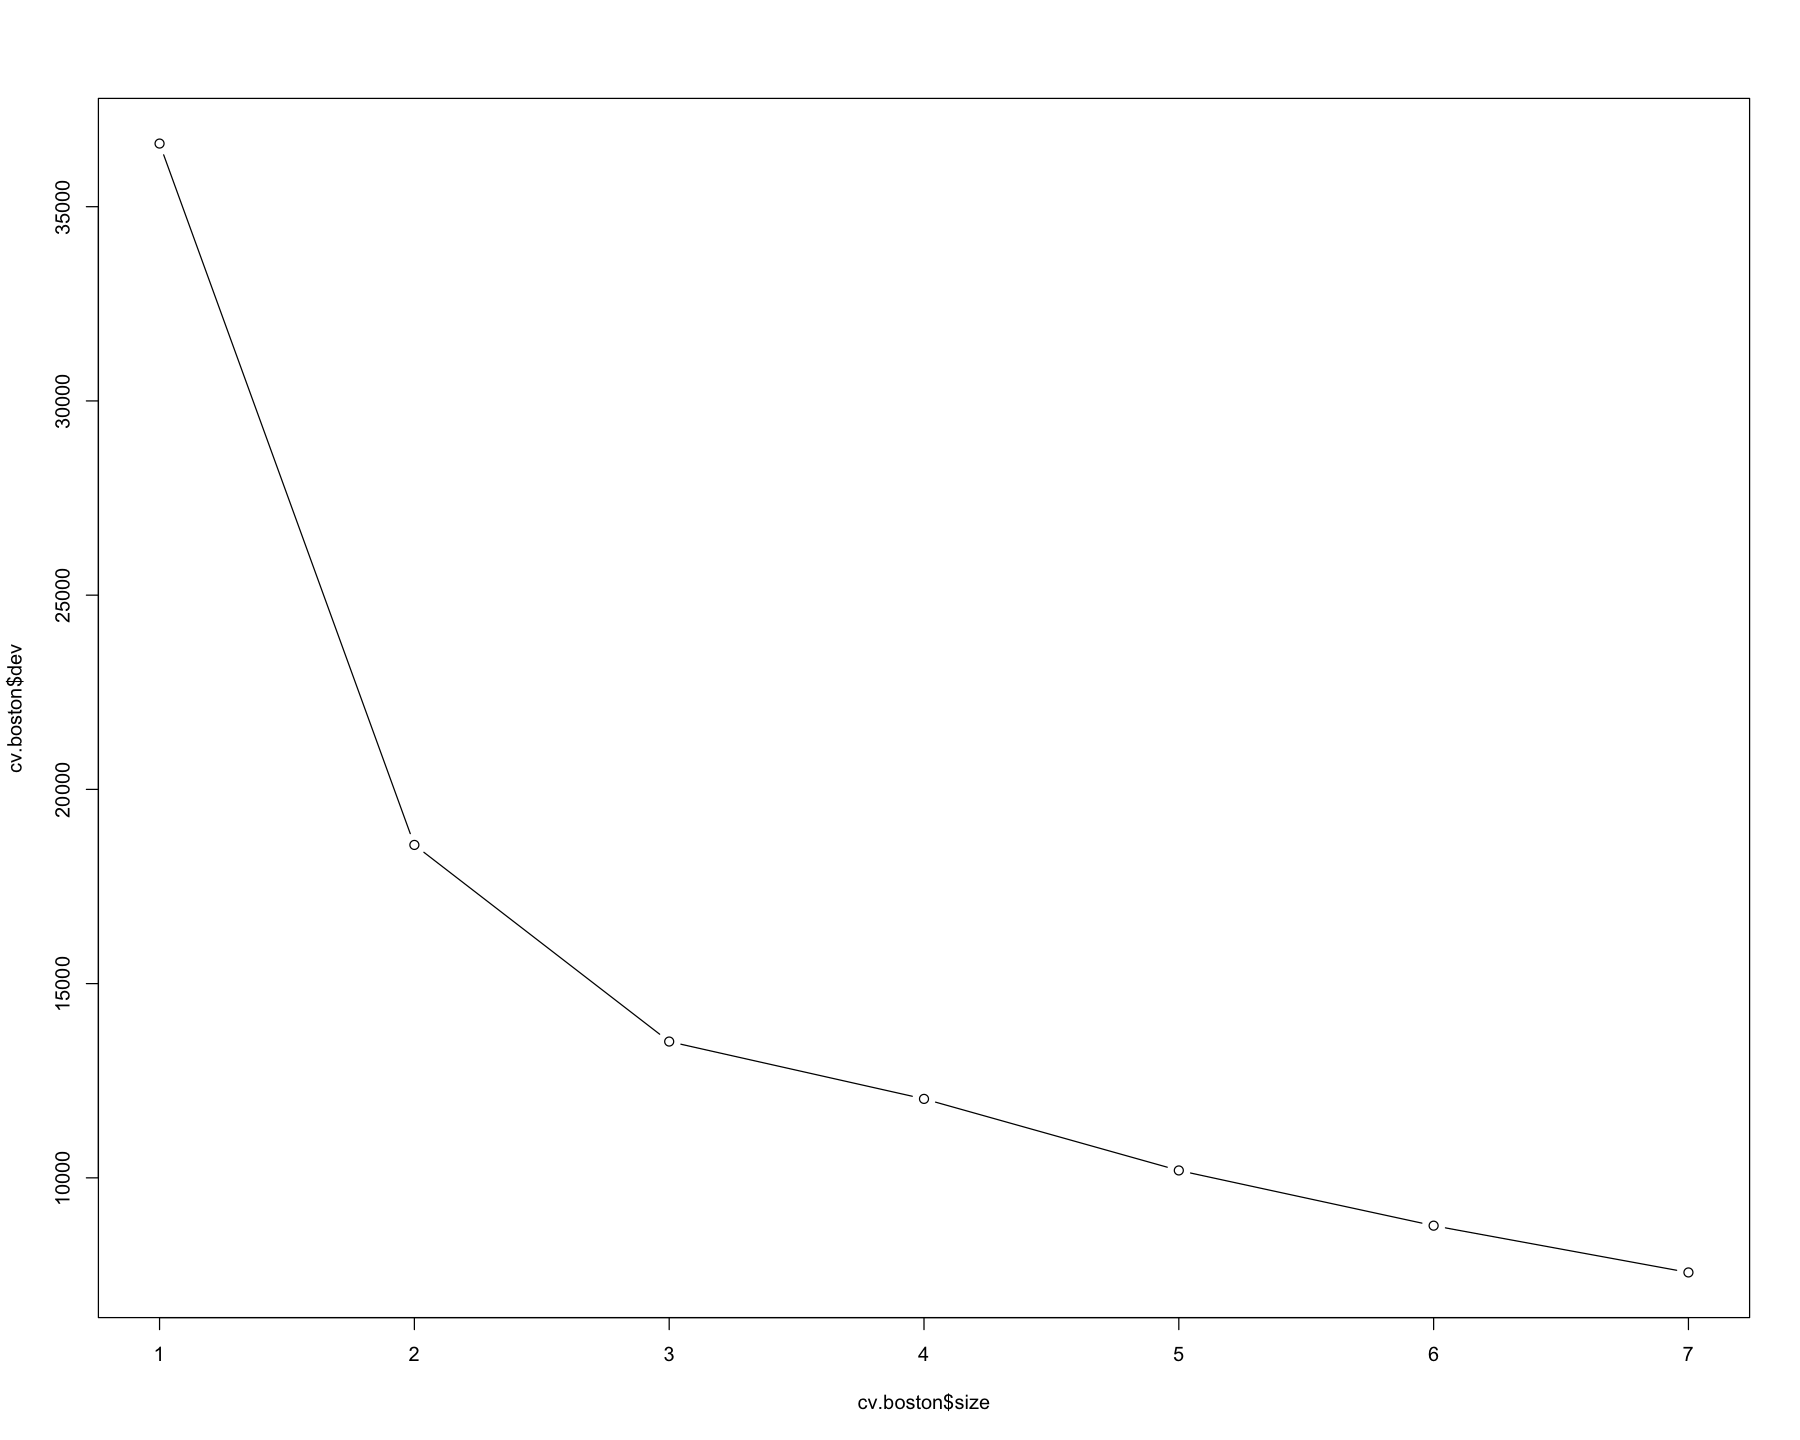

In [11]:
cv.boston = cv.tree(tree.boston)
plot(cv.boston$size, cv.boston$dev, type = "b")

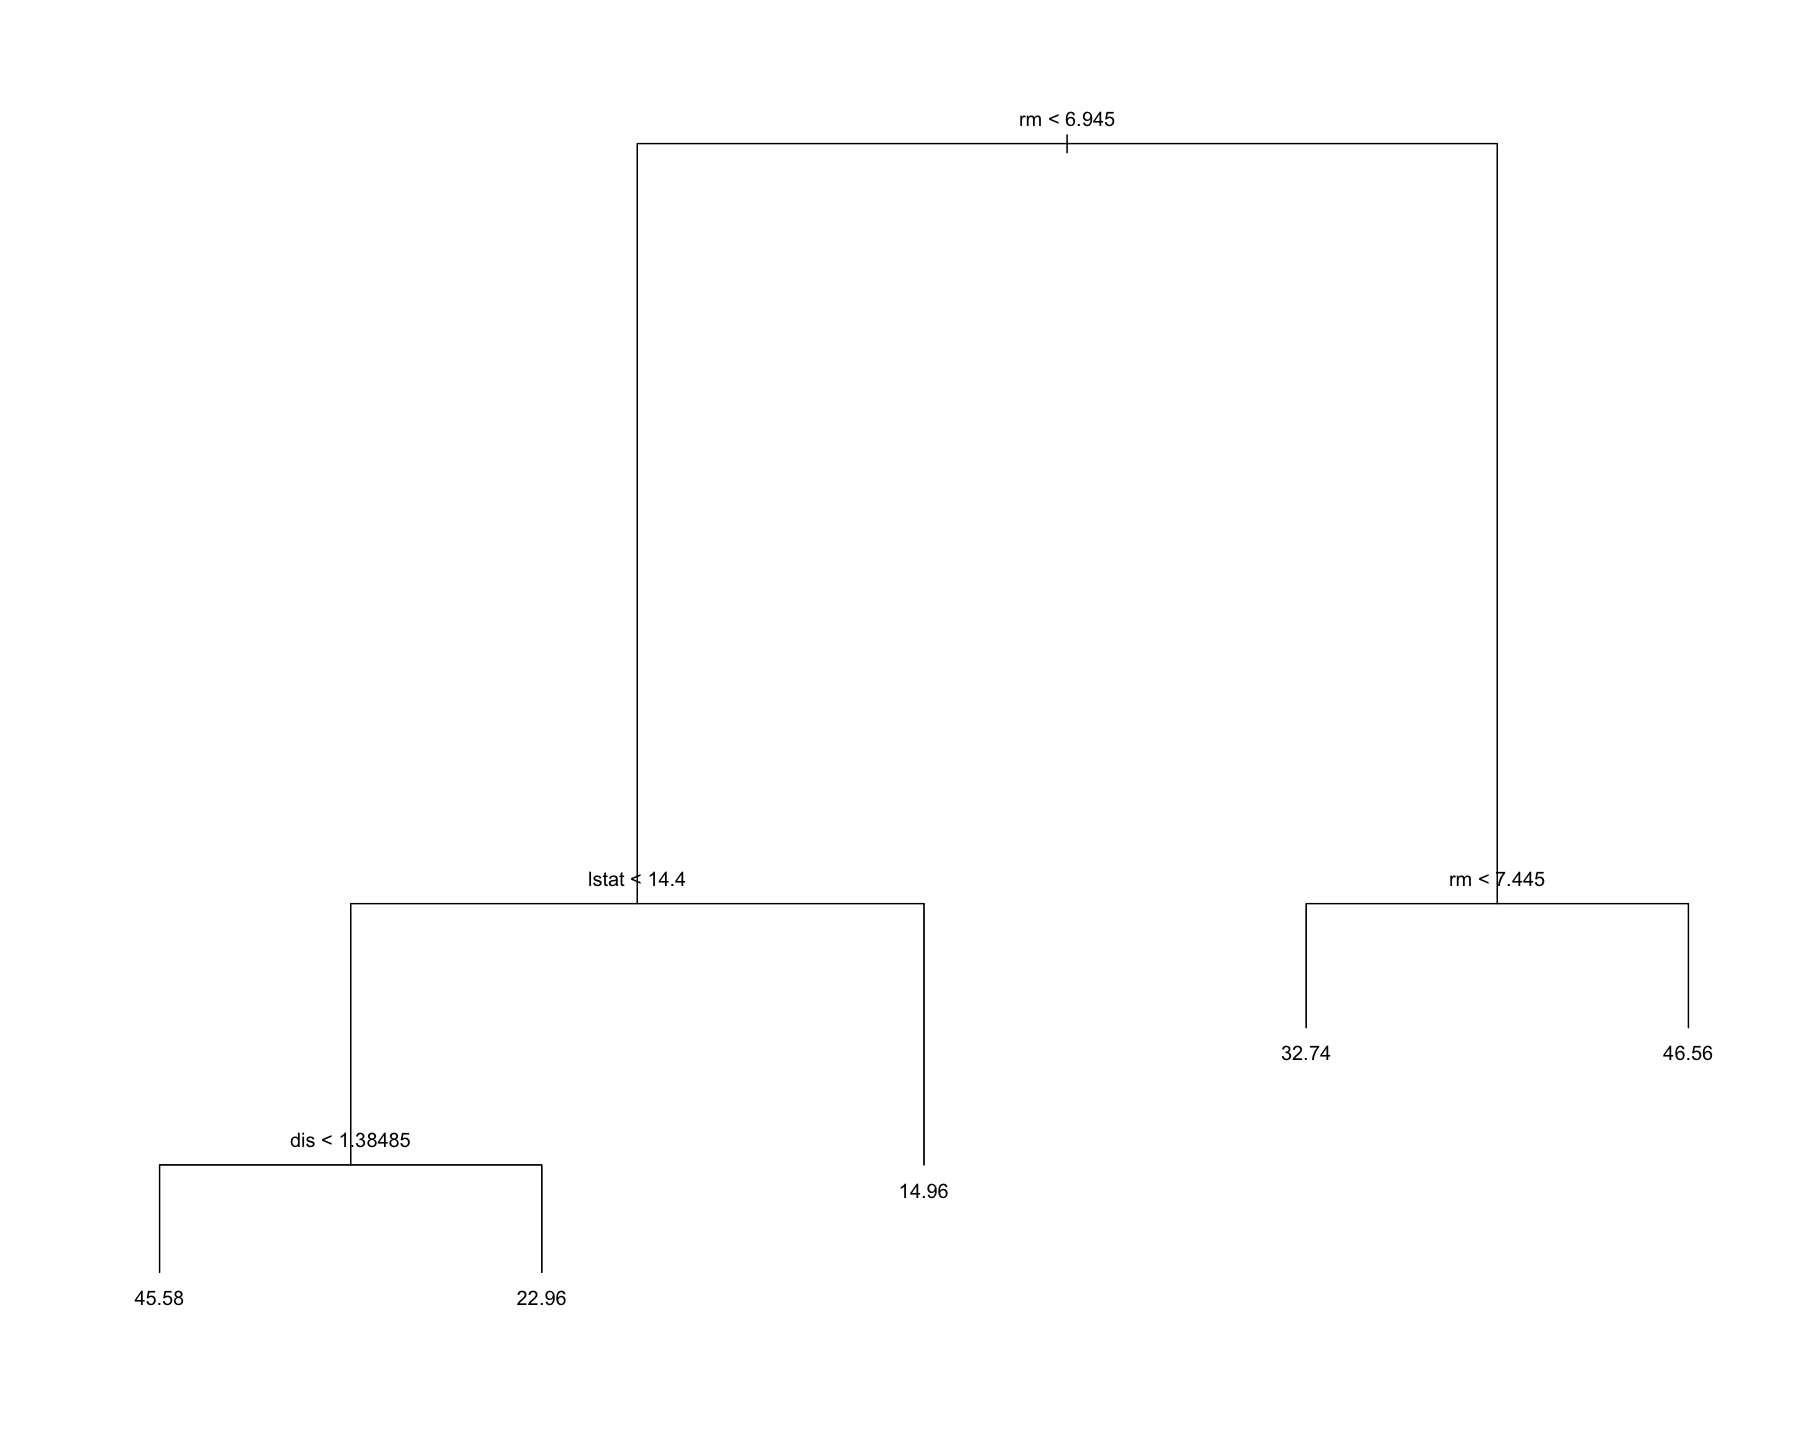

In [12]:
prune.boston = prune.tree(tree.boston, best = 5)
plot(prune.boston)
text(prune.boston, pretty = 0)

[1] 29.91626

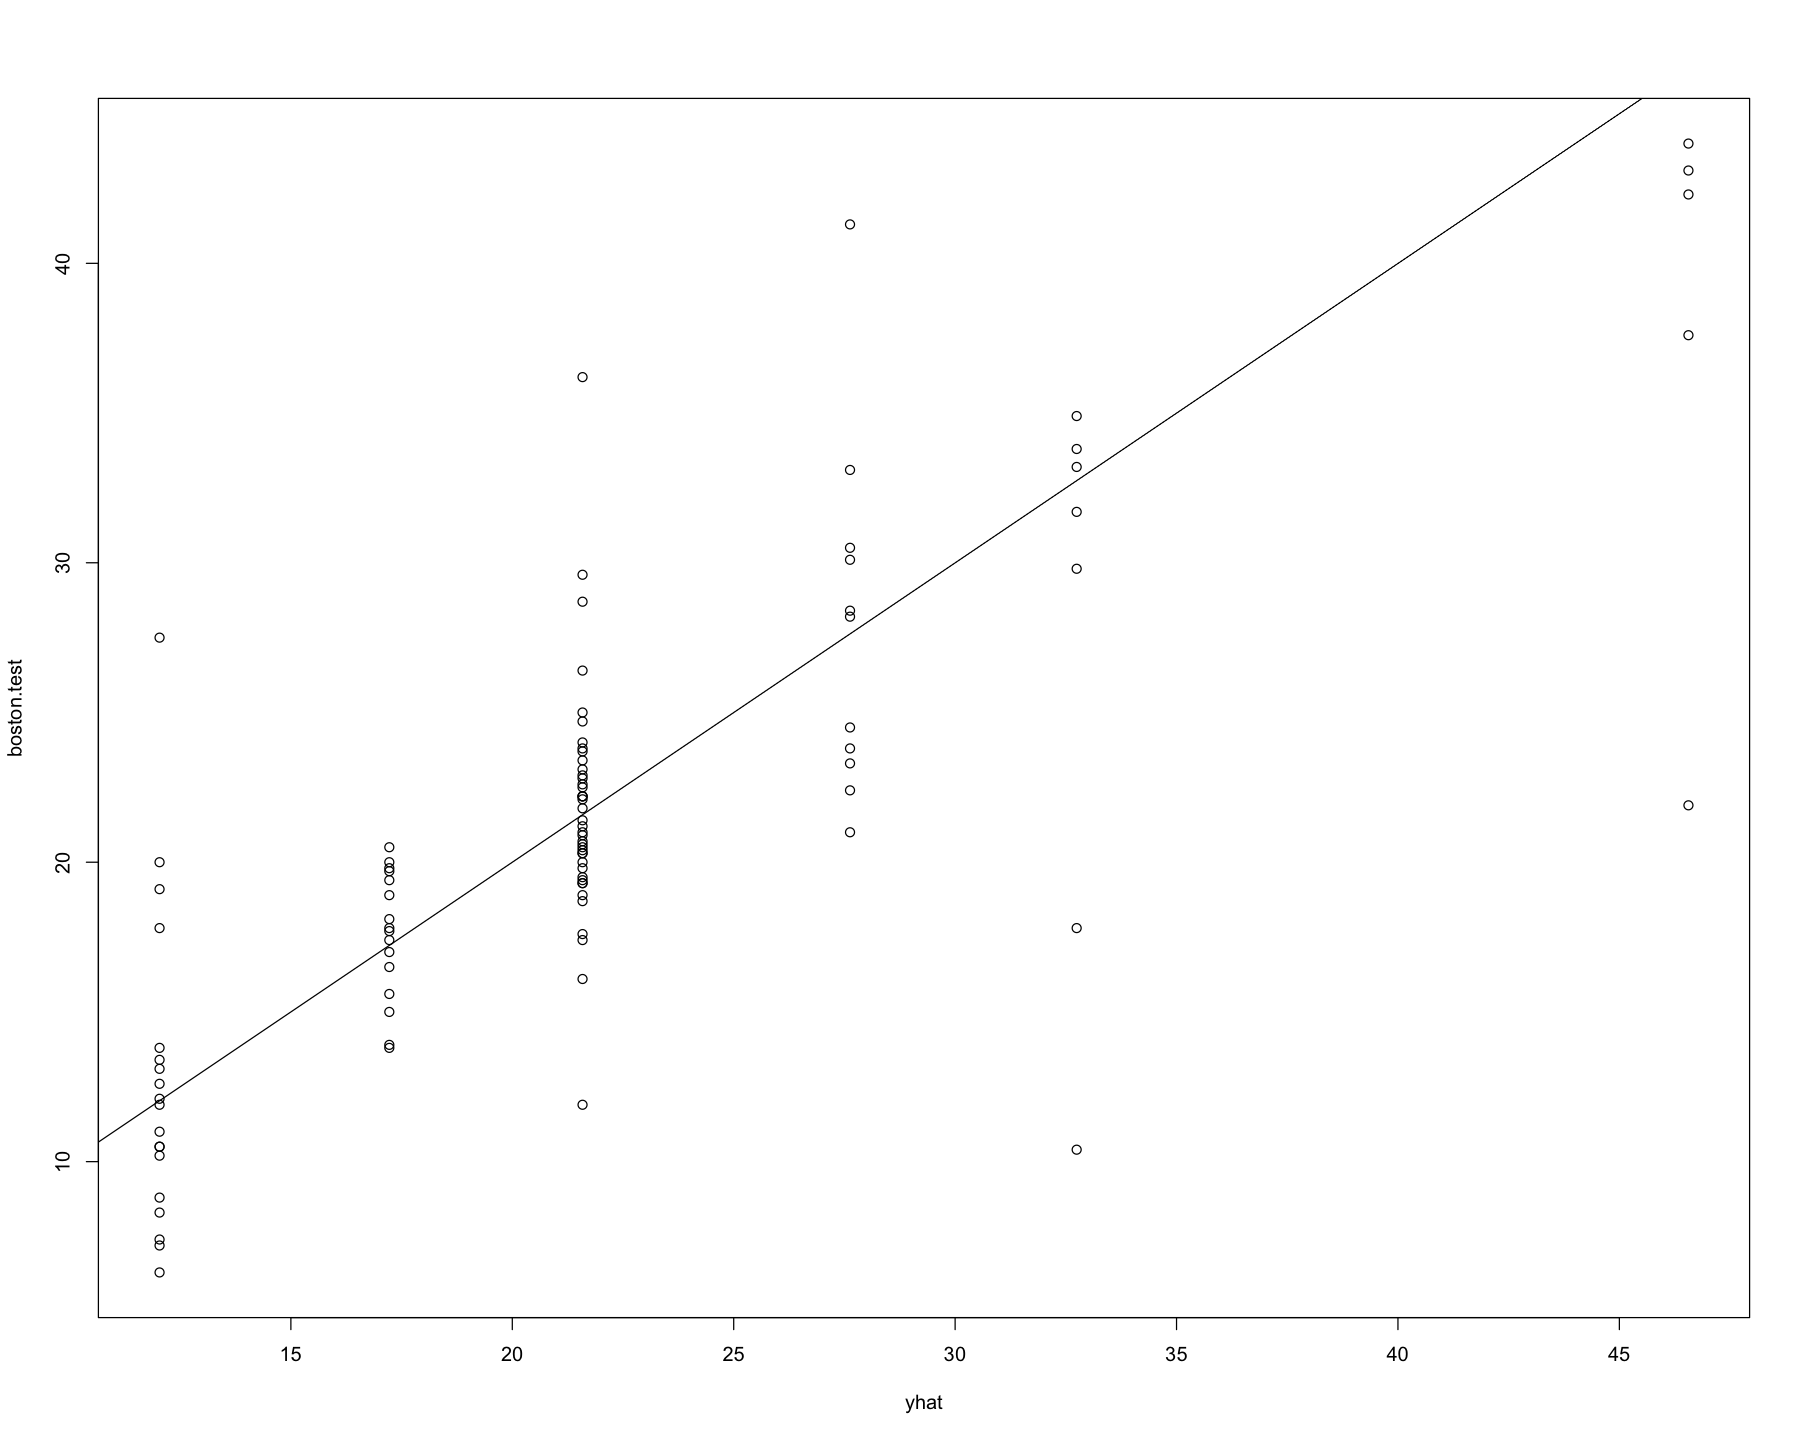

In [13]:
yhat = predict(tree.boston, newdata = Boston[-train , ])
boston.test = Boston[-train, "medv"]
plot(yhat, boston.test)
abline(0, 1)
mean((yhat - boston.test)^2)

In [14]:
set.seed(1)
bag.boston = randomForest(medv ~ ., data=Boston, subset=train, mtry=12, importance=T)
bag.boston


Call:
 randomForest(formula = medv ~ ., data = Boston, mtry = 12, importance = T,      subset = train) 
               Type of random forest: regression
                     Number of trees: 500
No. of variables tried at each split: 12

          Mean of squared residuals: 10.29572
                    % Var explained: 88.51

[1] 15.17034

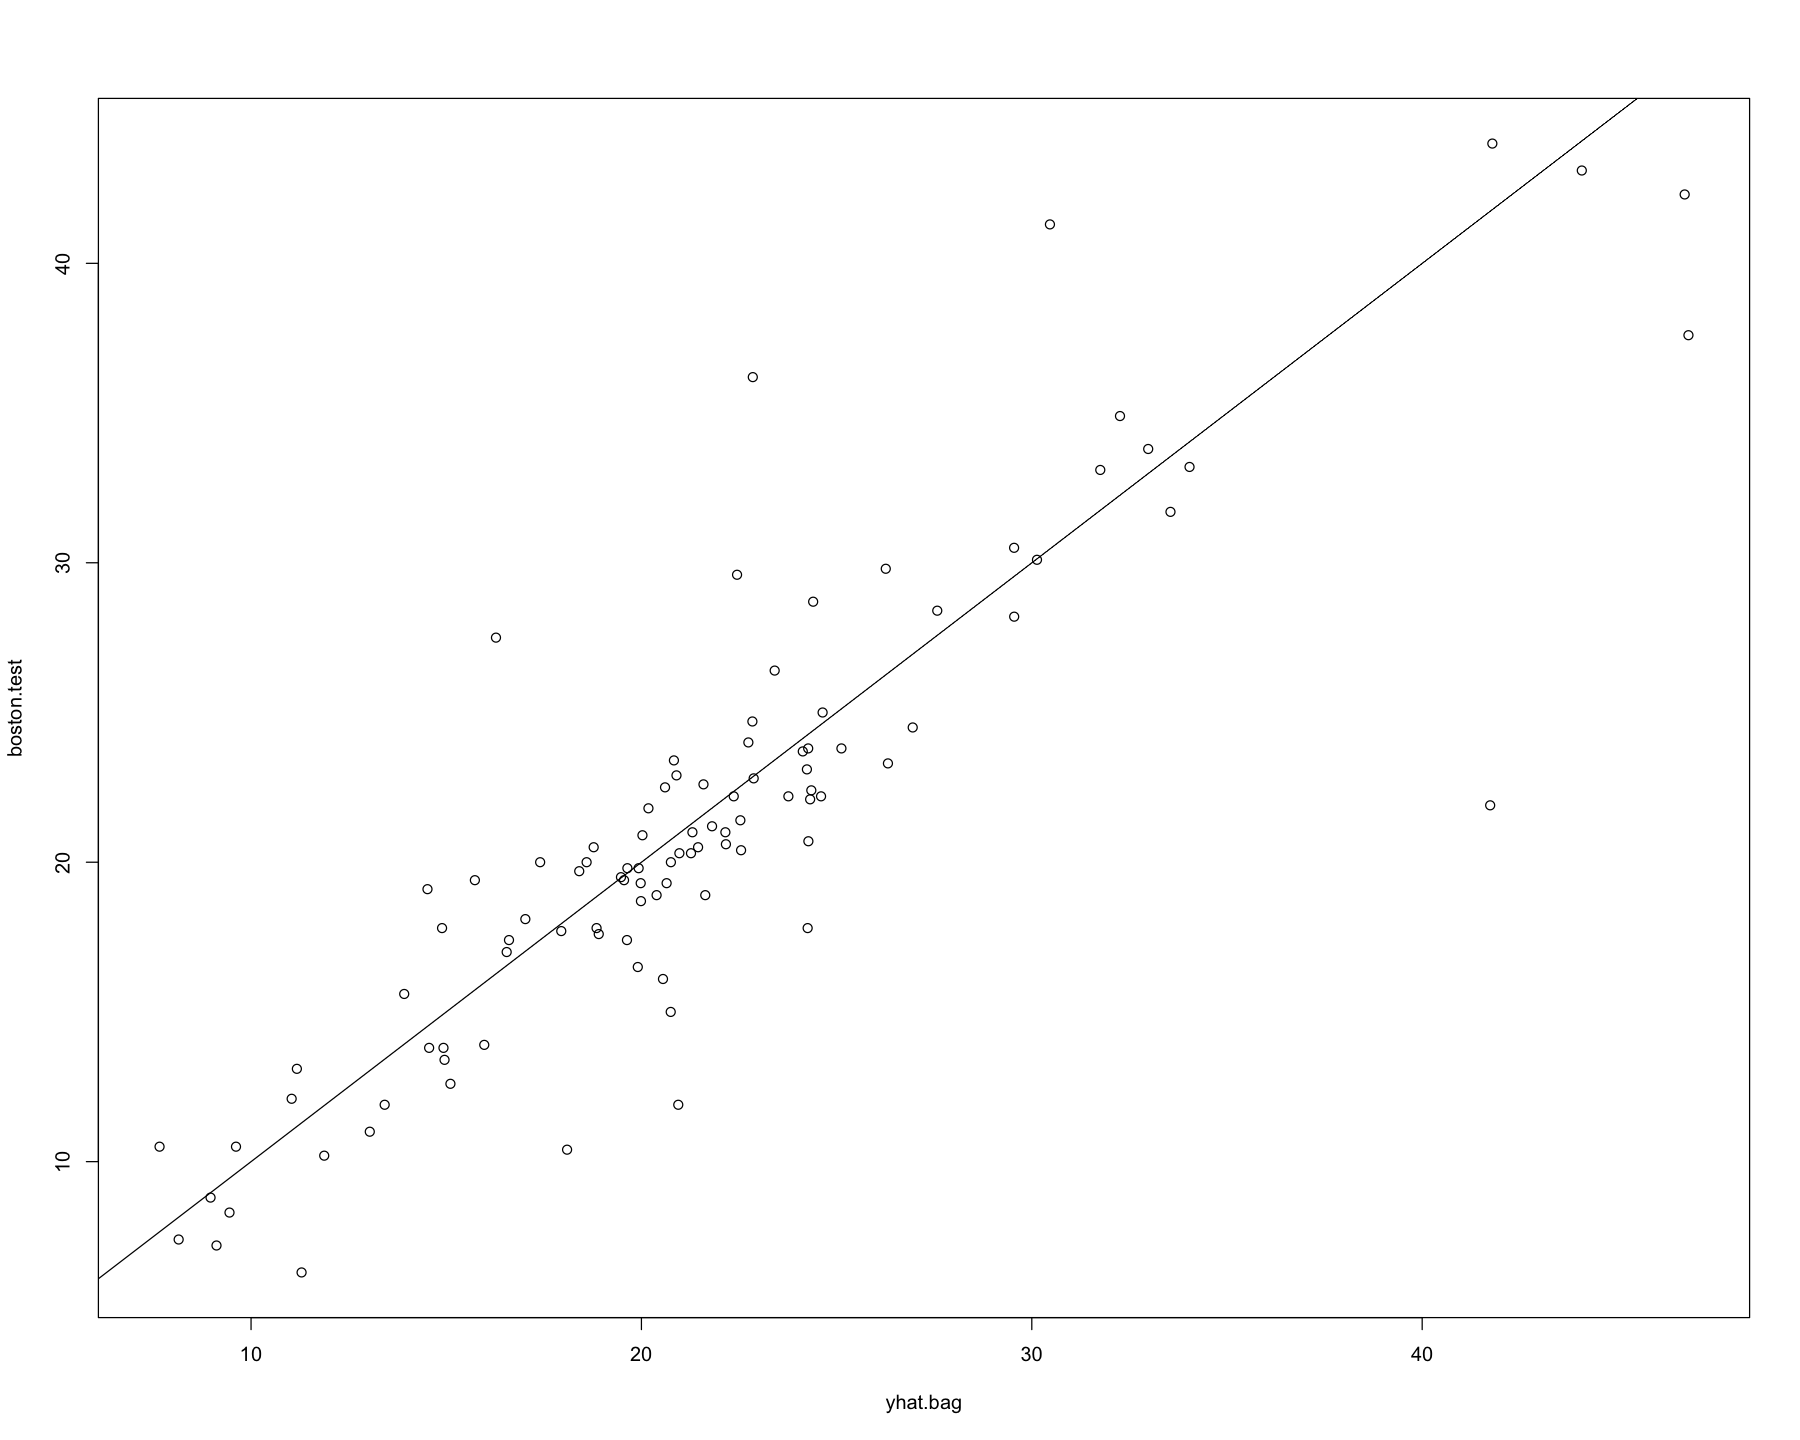

In [15]:
yhat.bag = predict(bag.boston, newdata=Boston[-train,])
plot(yhat.bag, boston.test)
abline (0, 1)
mean((yhat.bag - boston.test)^2)

In [16]:
bag.boston = randomForest(medv ~ ., data = Boston,
    subset = train, mtry = 12, ntree = 25)
yhat.bag = predict(bag.boston , newdata = Boston[-train , ])
mean((yhat.bag - boston.test)^2)

[1] 15.51967

In [17]:
set.seed (1)
rf.boston = randomForest(medv ~ ., data = Boston,
    subset = train , mtry = 6, importance = TRUE )
yhat.rf = predict(rf.boston , newdata = Boston[-train,])
mean((yhat.rf - boston.test)^2)

[1] 13.01872

In [18]:
importance(rf.boston)

,%IncMSE,IncNodePurity
crim,15.430472,1775.8036
zn,4.836746,104.2212
indus,10.088856,1415.9576
chas,1.908455,129.3676
nox,17.002292,1464.5336
rm,39.125134,12843.1481
age,13.468140,731.9503
dis,18.701347,2228.4728
rad,5.183828,170.5618
tax,9.227583,631.7436


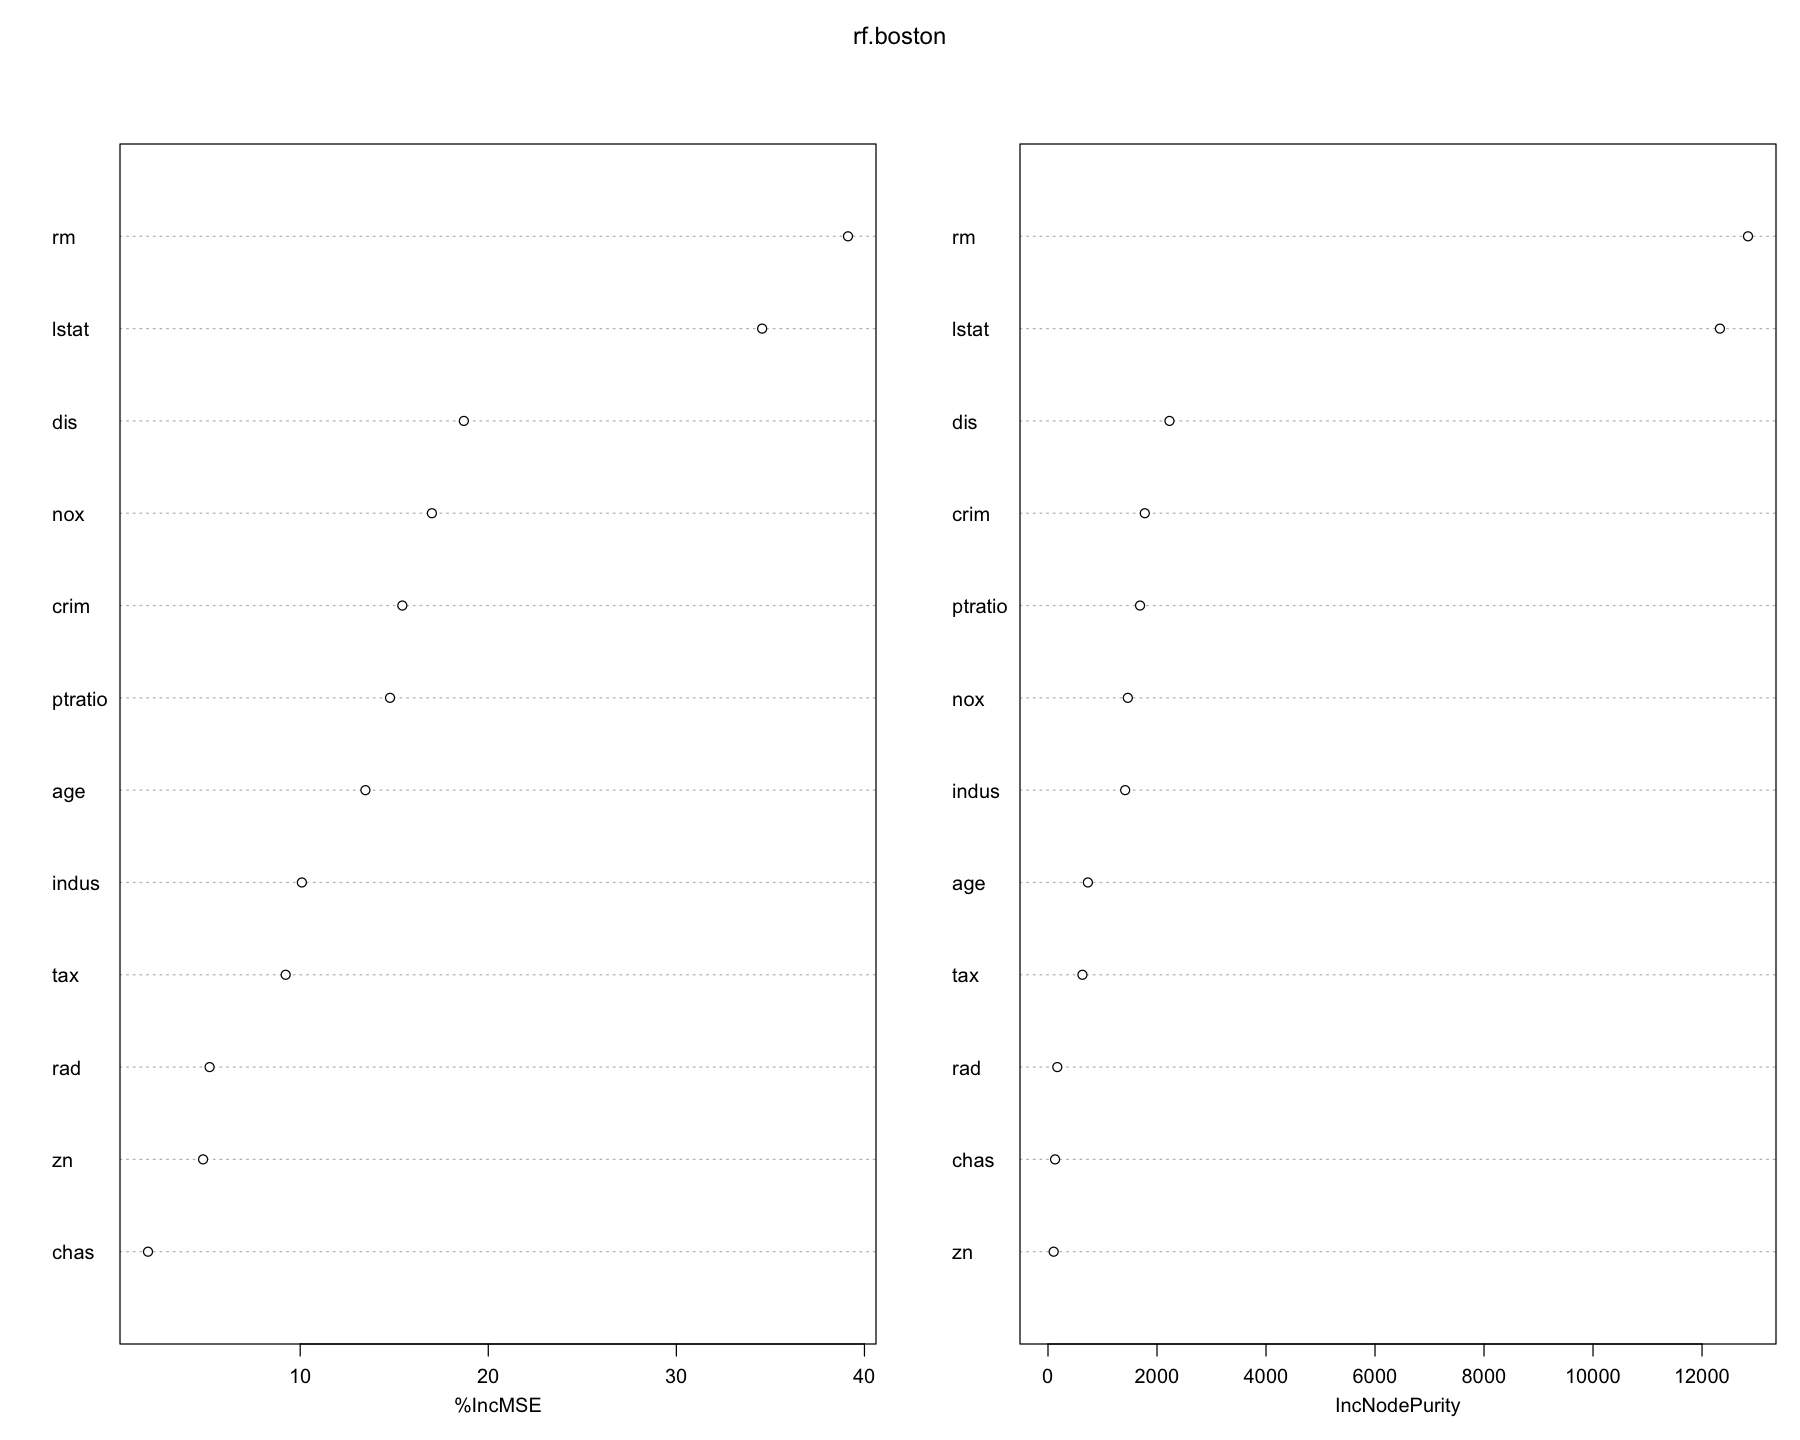

In [19]:
varImpPlot(rf.boston)

In [30]:
gaussian_dist <- gbm_dist("Gaussian")

,var,rel_inf
,<chr>,<dbl>
rm,rm,54.189281924
lstat,lstat,36.058776414
crim,crim,3.211699562
age,age,1.771267980
dis,dis,1.373422543
nox,nox,1.257619377
tax,tax,1.065701126
ptratio,ptratio,0.893907030
rad,rad,0.103064267


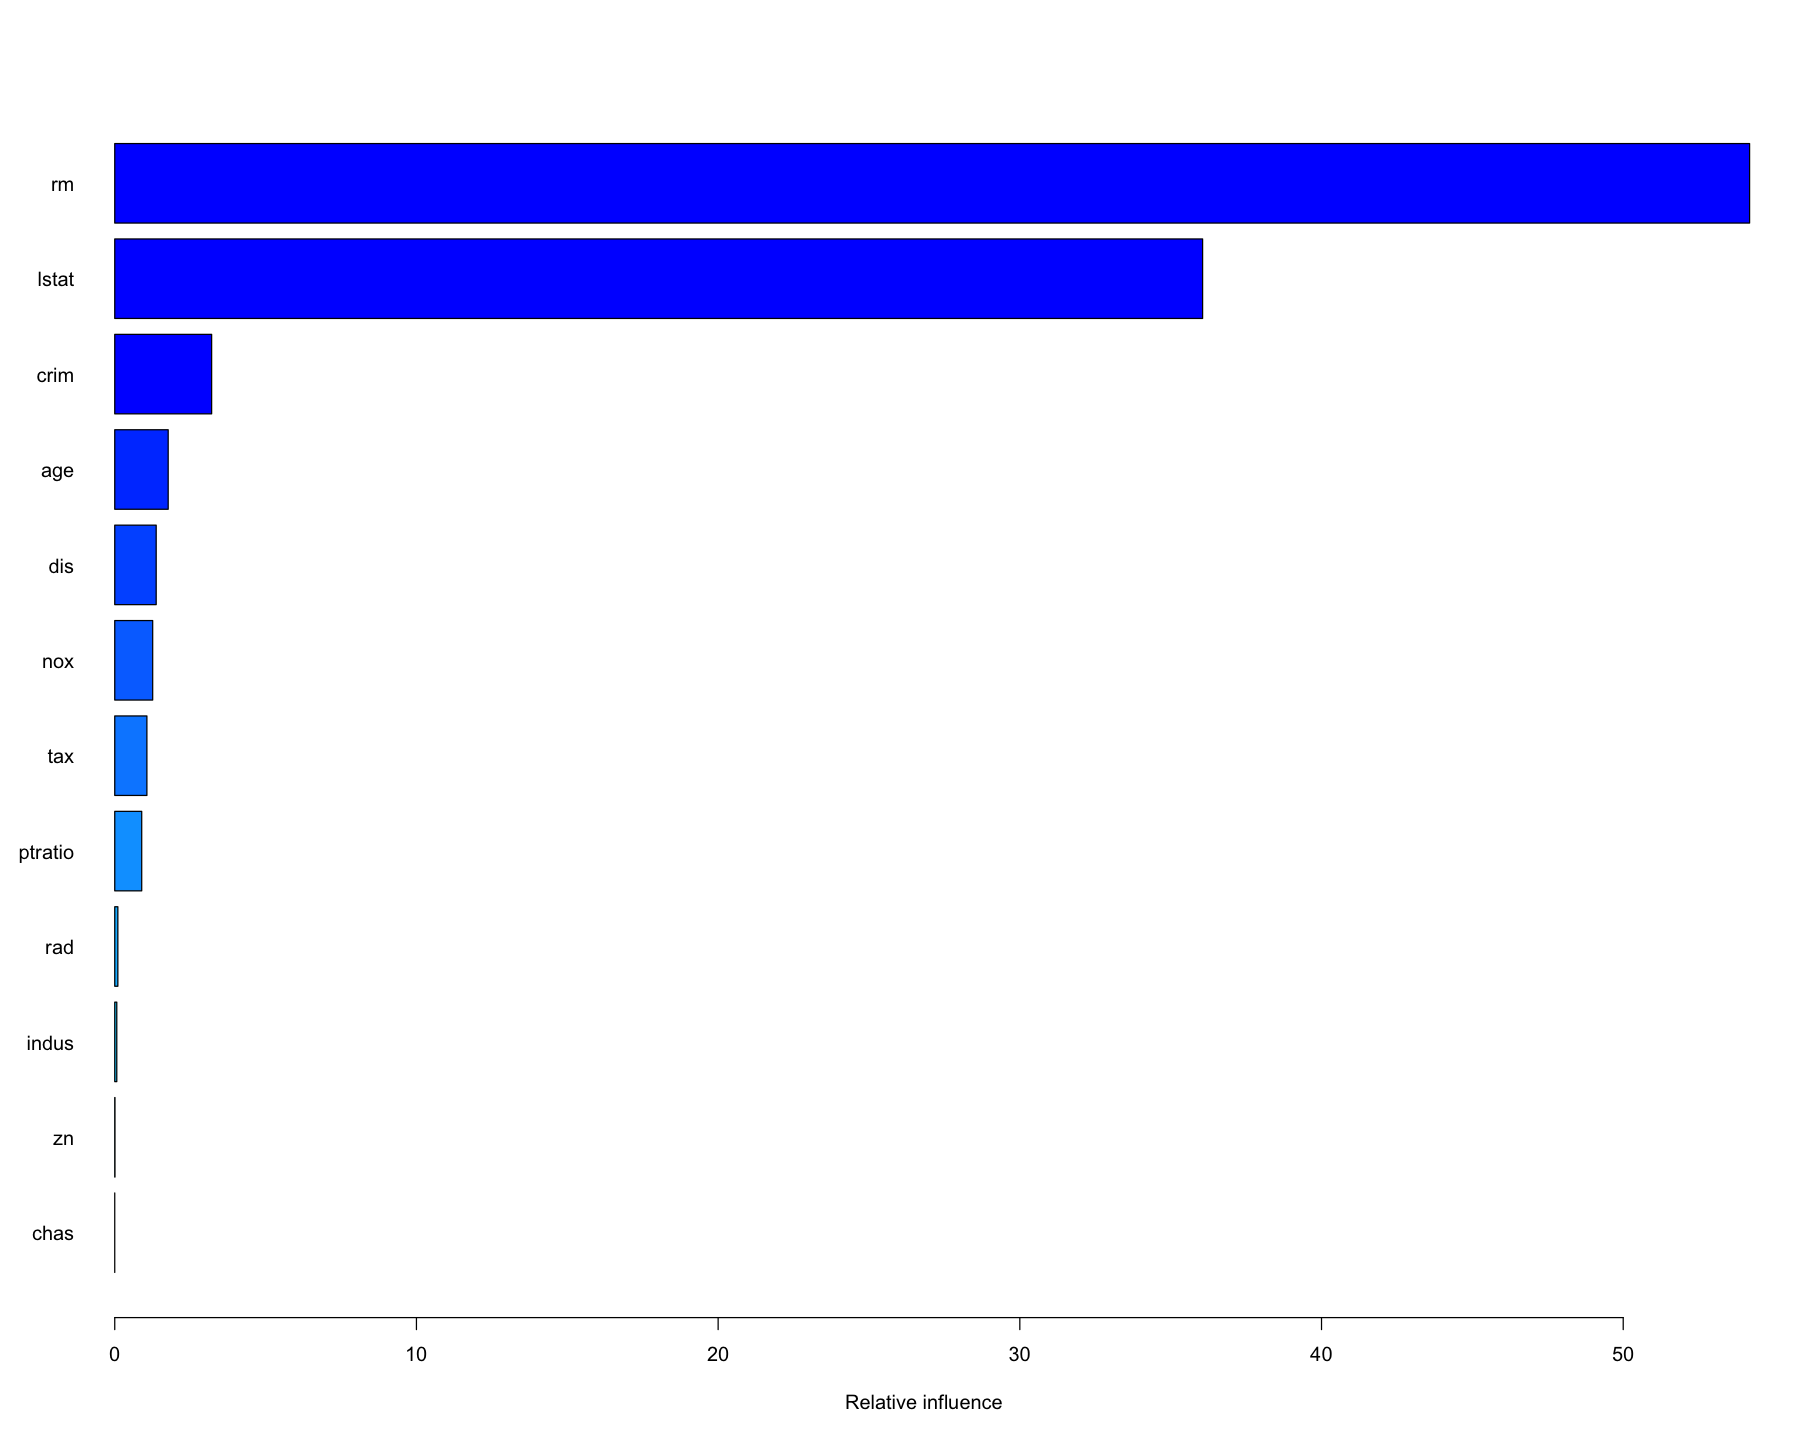

In [31]:
set.seed(1)
boost.boston = gbmt(medv ~ ., data = Boston[train,],
    distribution=gaussian_dist, cv_folds =5, keep_gbm_data = TRUE)
summary(boost.boston)

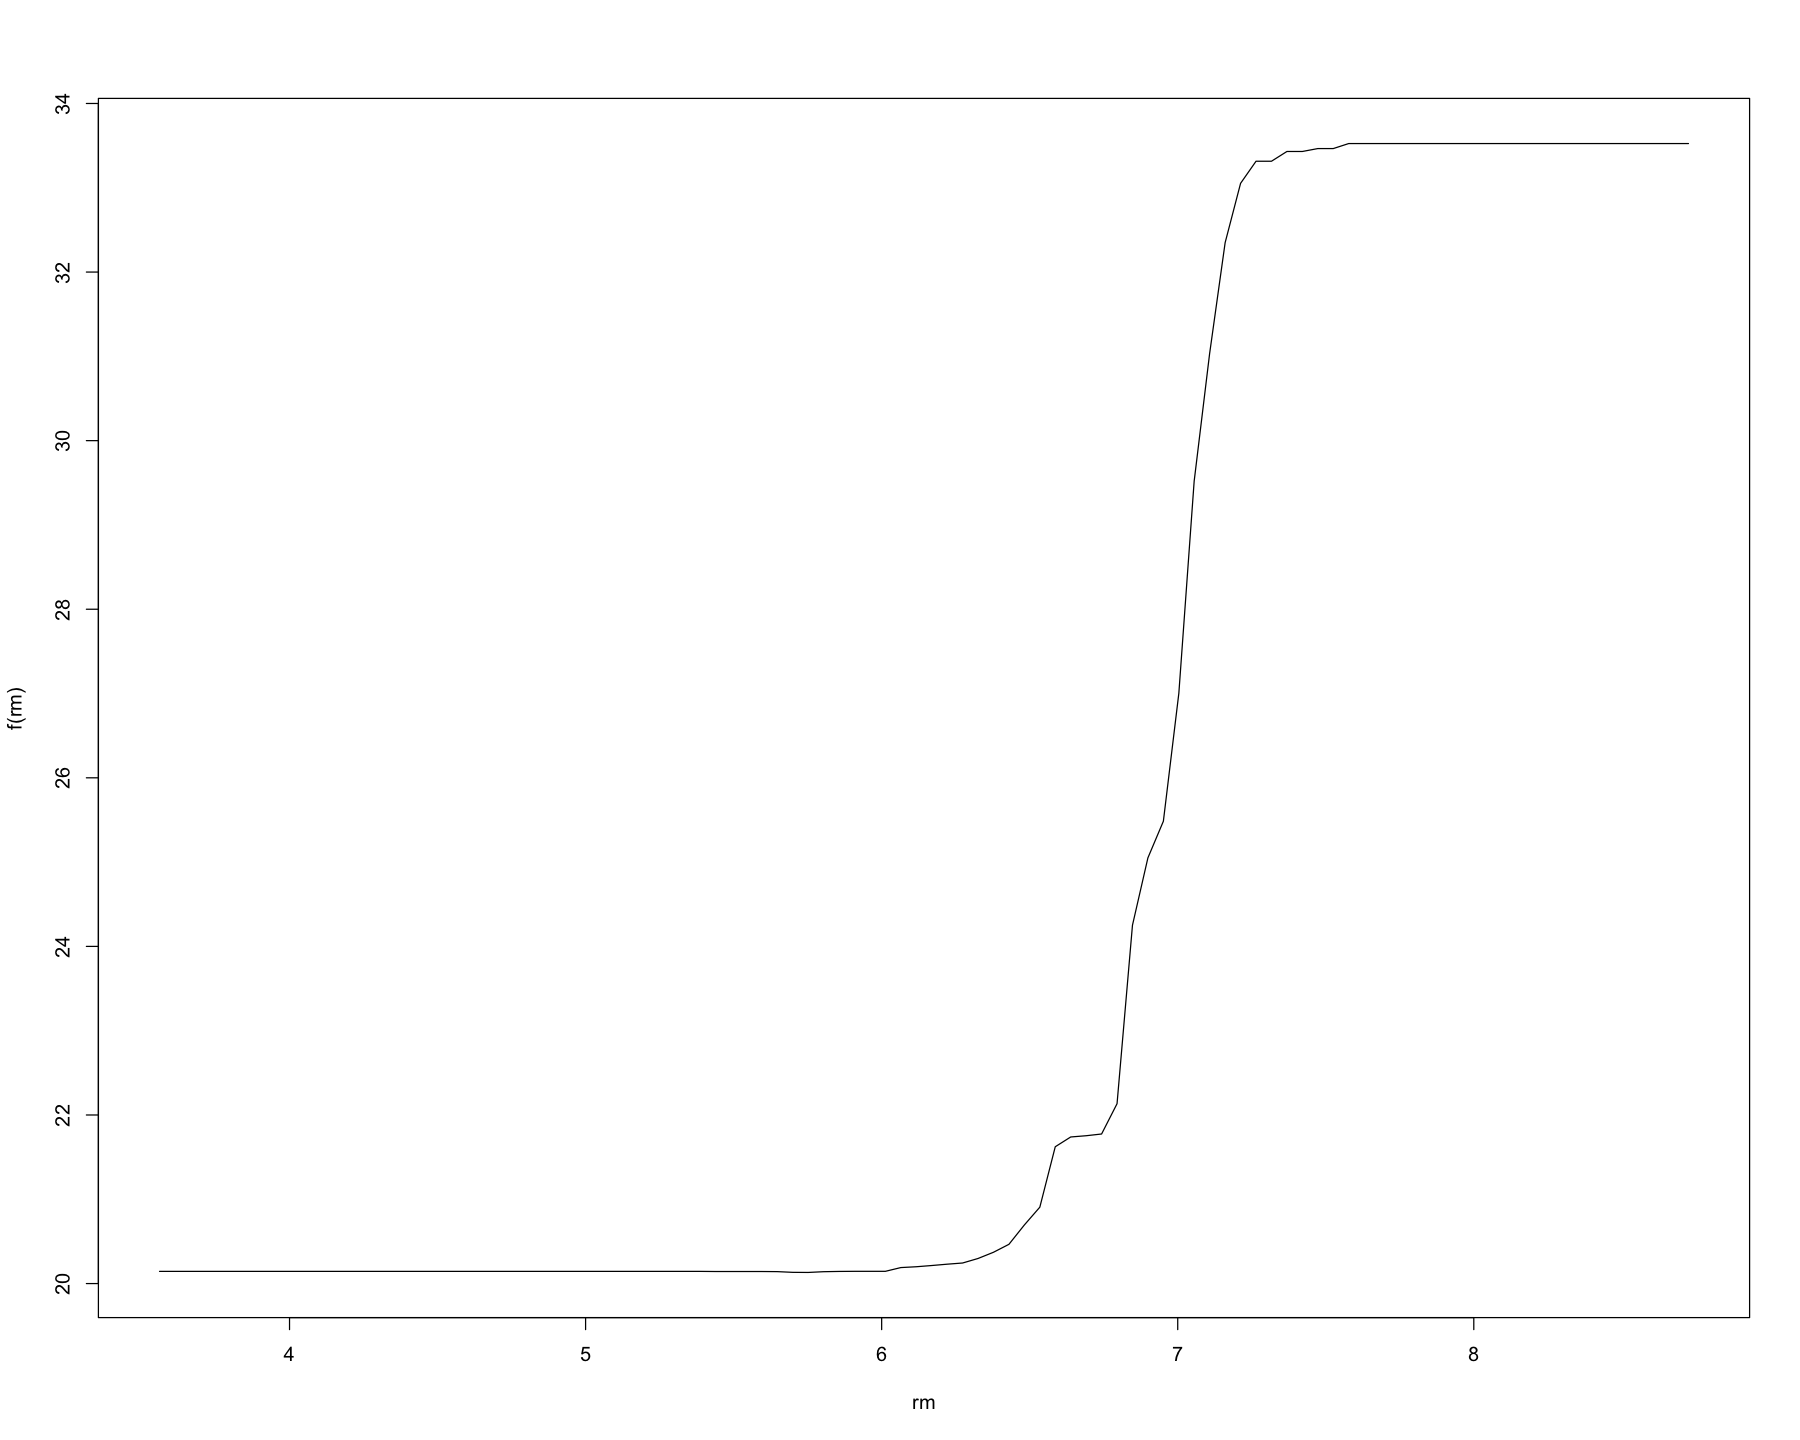

In [21]:
plot(boost.boston, var="rm")

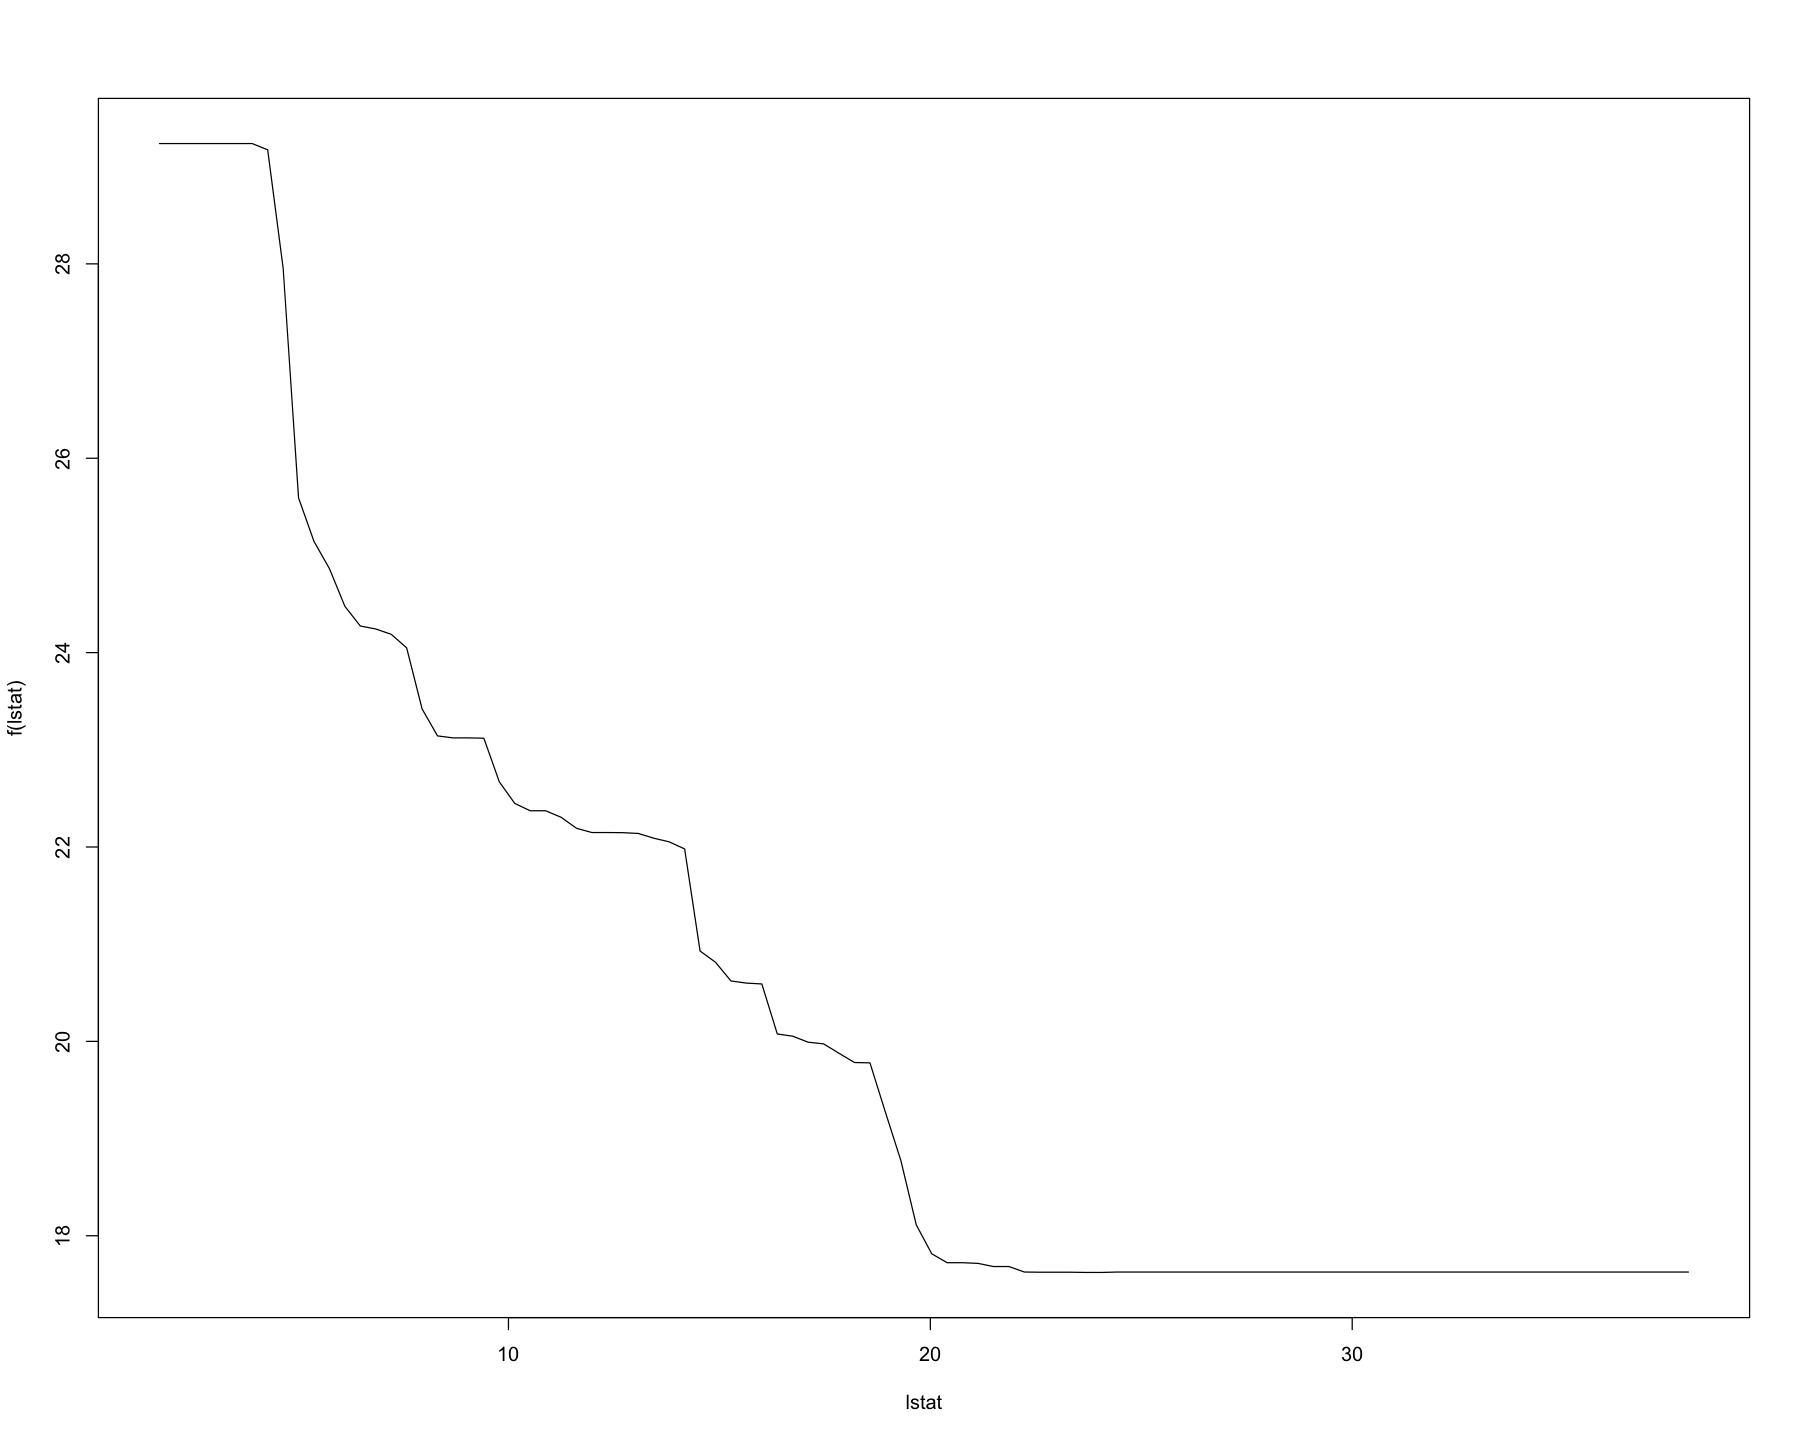

In [22]:
plot(boost.boston, var="lstat")

In [29]:
yhat.boost = predict(boost.boston, newdata = Boston[-train,], n.trees=2000)
mean((yhat.boost - boston.test)^2)

[1] 16.48295

In [24]:
boost.boston = gbmt(medv ~ ., data = Boston[train, ])
yhat.boost = predict(boost.boston, newdata = Boston[-train, ], n.trees = 2000)
mean((yhat.boost - boston.test)^2)

Distribution not specified, assuming Gaussian ...



[1] 16.48295

In [25]:
library(BART)

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


Loading required package: survival



In [26]:
x <- Boston[, 1:12]
y = Boston[, "medv"]
xtrain = x[train , ]
ytrain = y[train]
xtest = x[-train, ]
ytest = y[-train]
set.seed(1)
bartfit <- gbart(xtrain, ytrain, x.test = xtest)

*****Calling gbart: type=1
*****Data:
data:n,p,np: 406, 12, 100
y1,yn: -0.849261, 0.950739
x1,x[n*p]: 0.109590, 11.100000
xp1,xp[np*p]: 0.029850, 7.880000
*****Number of Trees: 200
*****Number of Cut Points: 100 ... 100
*****burn,nd,thin: 100,1000,1
*****Prior:beta,alpha,tau,nu,lambda,offset: 2,0.95,0.795495,3,4.82601,22.8493
*****sigma: 4.977477
*****w (weights): 1.000000 ... 1.000000
*****Dirichlet:sparse,theta,omega,a,b,rho,augment: 0,0,1,0.5,1,12,0
*****printevery: 100

MCMC
done 0 (out of 1100)
done 100 (out of 1100)
done 200 (out of 1100)
done 300 (out of 1100)
done 400 (out of 1100)
done 500 (out of 1100)
done 600 (out of 1100)
done 700 (out of 1100)
done 800 (out of 1100)
done 900 (out of 1100)
done 1000 (out of 1100)
time: 1s
trcnt,tecnt: 1000,1000


In [27]:
yhat.bart = bartfit$yhat.test.mean
mean((ytest - yhat.bart)^2)

[1] 15.47422

In [28]:
ord = order(bartfit$varcount.mean, decreasing = T)
bartfit$varcount.mean [ord]

nox   lstat     rad      rm     tax    chas   indus ptratio     dis     age 
 25.984  24.253  22.488  22.293  20.652  20.177  19.623  19.516  18.840  17.683 
     zn    crim 
 16.263  14.168